In [1]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\rpran\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
df_DA_US = df[(df['job_title_short']== 'Data Analyst') & (df['job_location'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset='salary_year_avg')
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_US_toppay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)
df_DA_US_topskills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)



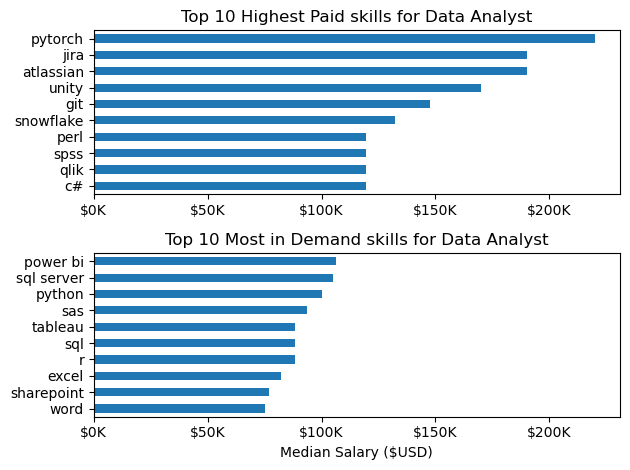

In [19]:
fig, ax = plt.subplots(2,1)

df_DA_US_toppay[::-1].plot(kind='barh', y='median', ax= ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
df_DA_US_topskills[::-1].plot(kind='barh', y='median', ax= ax[1], legend=False)
ax[1].set_title('Top 10 Most in Demand skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()

In [10]:
df_DA_US_topskills

,count,median
job_skills,,
sql,20,88500.00
tableau,16,88500.00
python,15,100000.00
excel,14,82258.75
power bi,10,106400.00
word,8,75033.75
r,8,88500.00
sharepoint,5,77017.50
sas,4,93525.00
